In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from PIL import Image
import cv2

In [2]:
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = ROOT_DIR / "data" / "processed"
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

# Import biến cụ thể từ file configs/config.py
from configs.config import FEATURE_COLS

train_file = DATA_DIR / "df_dataset.csv"
test1_file = DATA_DIR / "df_testing_1.csv"
test2_file = DATA_DIR / "df_testing_2.csv"

df_train = pd.read_csv(train_file)
df_test1 = pd.read_csv(test1_file)
df_test2 = pd.read_csv(test2_file)

df_test = pd.concat([df_test1, df_test2], ignore_index=True)

df_train["label"] = df_train["label"].replace({"jd": "jg"}).str.strip()
df_test["label"]  = df_test["label"].replace({"jd": "jg"}).str.strip()

print(f"Tập Train : {df_train.shape[0]} mẫu, {df_train.shape[1]} cột")
print(f"Tập Test  : {df_test.shape[0]} mẫu ({len(df_test1)} + {len(df_test2)})")
print(f"Số loài   : {df_train['label'].nunique()} loài")

Tập Train : 6000 mẫu, 60 cột
Tập Test  : 1200 mẫu (600 + 600)
Số loài   : 60 loài


# 1. Thống kê hình học & Kích thước ảnh

- Phân phối tỷ lệ khung hình (Aspect Ratio Distribution)

- Tỷ lệ diện tích lá trên khung hình (Foreground-to-Background Ratio)

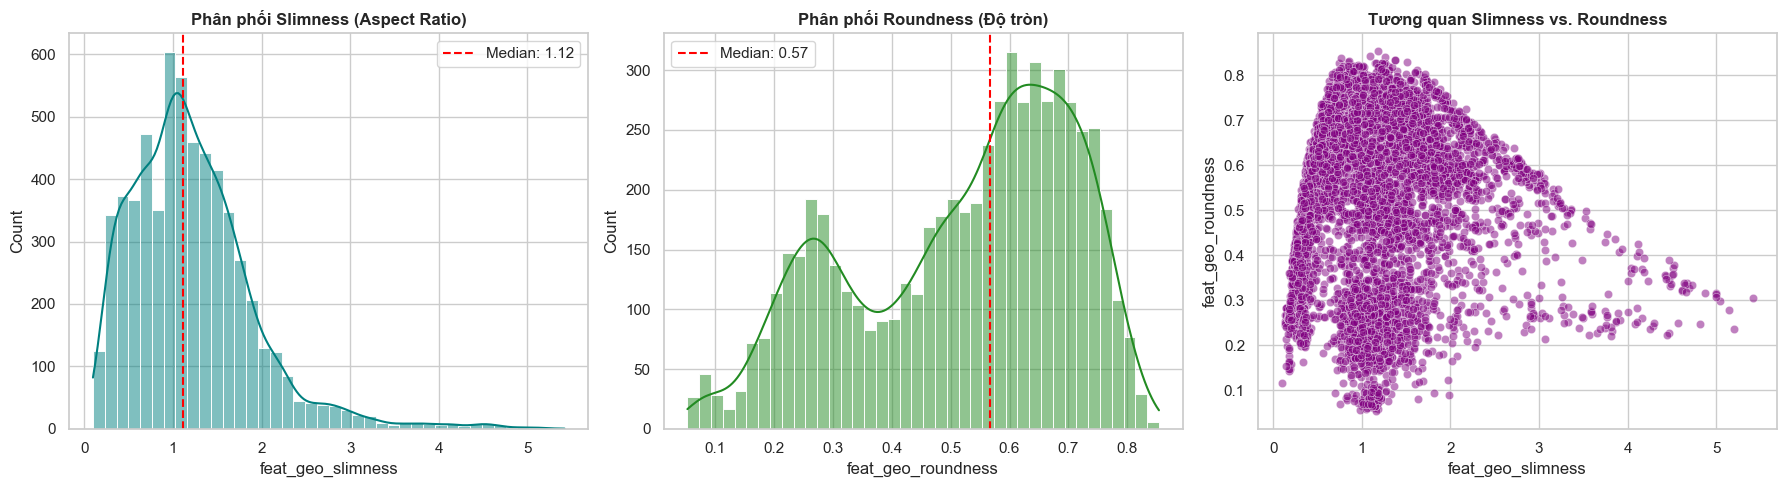

TOP 5 LOÀI LÁ DÀI HẸP NHẤT (Slimness cao nhất):


label
bint     2.534654
dracb    2.353255
zam      2.258570
bl       2.173661
zamcu    1.970222
Name: feat_geo_slimness, dtype: float64


TOP 5 LOÀI LÁ TRÒN NHẤT (Roundness cao nhất):


label
pb        0.780192
fictr     0.761196
epiac     0.749196
begora    0.747597
begro     0.733728
Name: feat_geo_roundness, dtype: float64

In [7]:
from configs.config import GEO_COLS

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Aspect Ratio
sns.histplot(df_train["feat_geo_slimness"], bins=40, kde=True, color="teal", ax=axes[0])
axes[0].axvline(df_train["feat_geo_slimness"].median(), color="red", linestyle="--", 
                label=f"Median: {df_train['feat_geo_slimness'].median():.2f}")
axes[0].set_title("Phân phối Slimness (Aspect Ratio)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("feat_geo_slimness")
axes[0].legend()

# Biểu đồ Roundness 
sns.histplot(df_train["feat_geo_roundness"], bins=40, kde=True, color="forestgreen", ax=axes[1])
axes[1].axvline(df_train["feat_geo_roundness"].median(), color="red", linestyle="--", 
                label=f"Median: {df_train['feat_geo_roundness'].median():.2f}")
axes[1].set_title("Phân phối Roundness (Độ tròn)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("feat_geo_roundness")
axes[1].legend()

#Tương quan Slimness vs Roundness
sns.scatterplot(data=df_train, x="feat_geo_slimness", y="feat_geo_roundness", 
                alpha=0.5, color="purple", ax=axes[2])
axes[2].set_title("Tương quan Slimness vs. Roundness", fontsize=12, fontweight="bold")
axes[2].set_xlabel("feat_geo_slimness")
axes[2].set_ylabel("feat_geo_roundness")

plt.tight_layout()
plt.show()

# Xếp hạng top các loài có hình dạng đặc trưng
print("=" * 60)
print("TOP 5 LOÀI LÁ DÀI HẸP NHẤT (Slimness cao nhất):")
display(df_train.groupby("label")["feat_geo_slimness"].mean().sort_values(ascending=False).head(5))

print("\nTOP 5 LOÀI LÁ TRÒN NHẤT (Roundness cao nhất):")
display(df_train.groupby("label")["feat_geo_roundness"].mean().sort_values(ascending=False).head(5))
print("=" * 60)

Độ lệch phân phối: feat_geo_slimness lệch phải rõ rệt với trung vị đạt 1.12, phản ánh đa số loài có phiến lá thon dài vừa phải, trong khi nhóm cá biệt như bint ($2.53$) hay dracb ($2.35$) có dạng lá dải rất hẹp.

Phân cụm hình thái: feat_geo_roundness thể hiện dạng phân phối đa đỉnh với trung vị 0.57, tách biệt rõ nhóm lá xẻ thùy/mảnh hẹp (đỉnh $\approx 0.27$) với nhóm lá tròn/khiên đầy đặn (đỉnh $\approx 0.65$, dẫn đầu là pb và fictr đạt $> 0.76$).

Mối quan hệ đánh đổi (Trade-off): Biểu đồ tương quan khẳng định nghịch lý hình học: khi độ thuôn dài (Slimness) tăng thì độ tròn (Roundness) suy giảm nghiêm trọng về dưới $0.3$.


# 2. Thống kê màu sắc đa không gian 
- Biểu đồ Histogram trên từng kênh màu (RGB vs. HSV/HSL)

- Color Moments (Mean, Std, Skewness, Kurtosis)

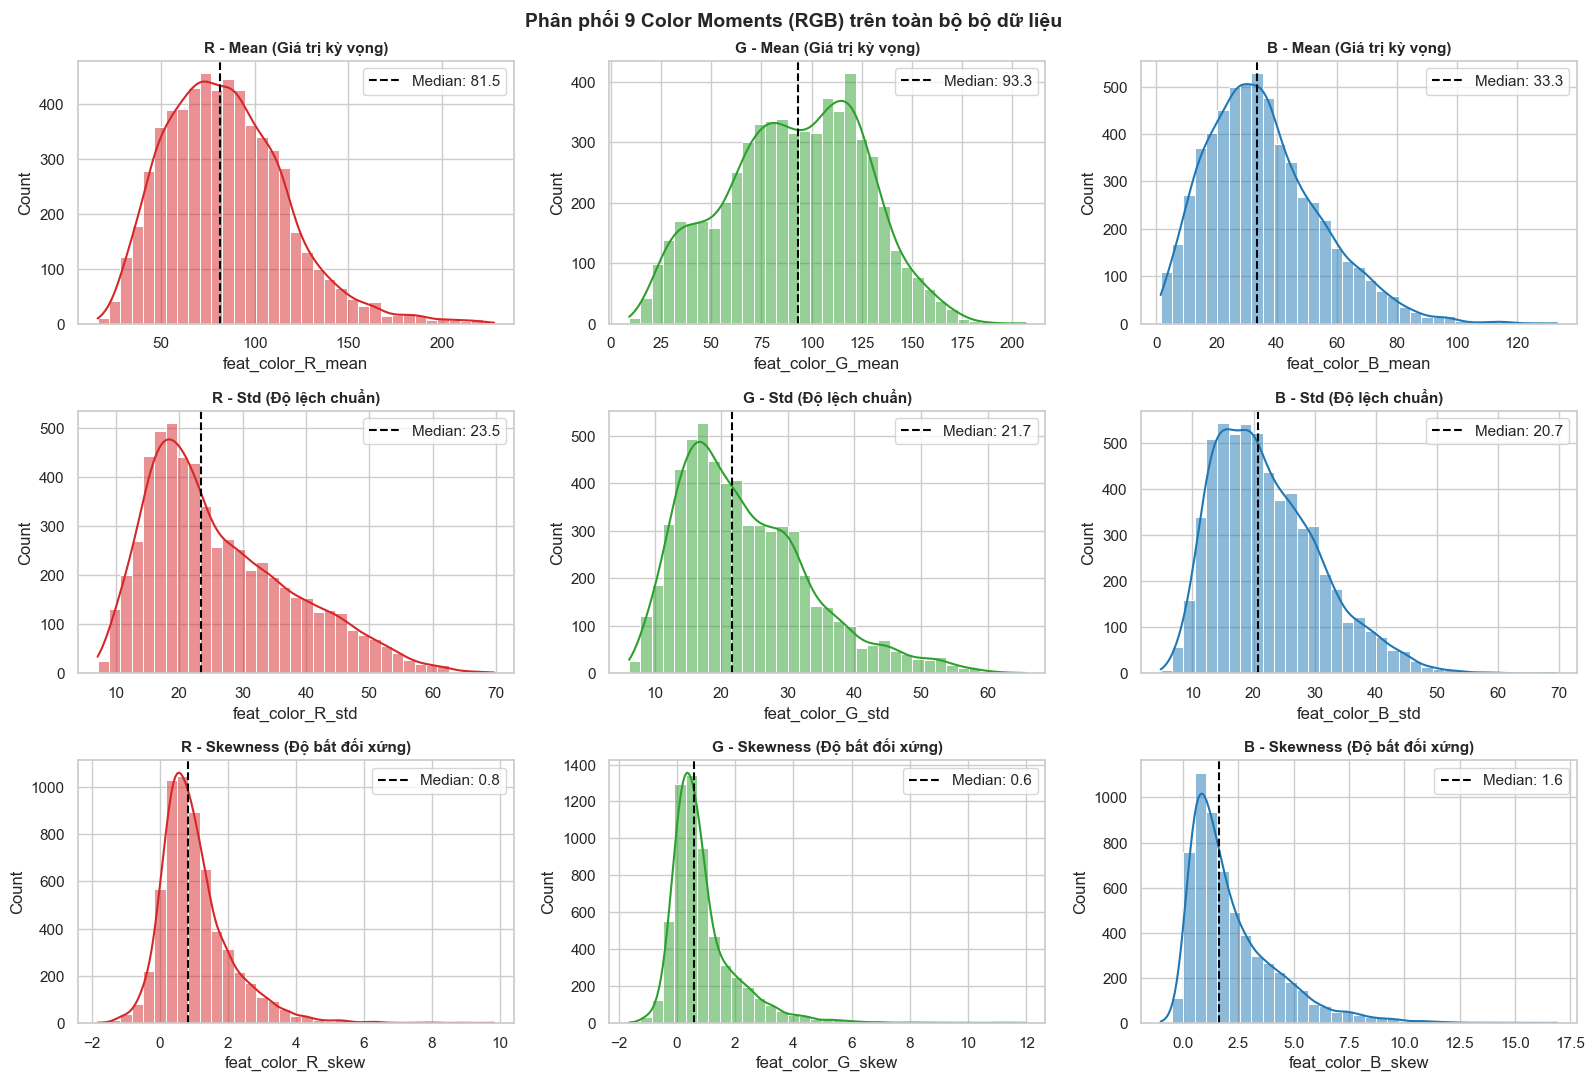

TOP 5 LOÀI CÓ SẮC TỐ ĐỎ CAO NHẤT (R Mean cao nhất):


label
aw       183.578499
E        134.658884
pmal     130.890113
scimq    129.703435
mb       126.115934
Name: feat_color_R_mean, dtype: float64


TOP 5 LOÀI CÓ ĐỘ PHÂN HÓA SẮC ĐỘ LỚN NHẤT (G Std cao nhất - lá đốm/variegated):


label
adv      49.666548
ps       47.900150
bl       38.270613
cisds    36.660830
manes    36.487760
Name: feat_color_G_std, dtype: float64

In [8]:
from configs.config import COLOR_COLS

# 1. Trực quan hóa phân phối của 9 Color Moments trên tập Train
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
channels = ['R', 'G', 'B']
moments = [('mean', 'Mean (Giá trị kỳ vọng)'), 
           ('std', 'Std (Độ lệch chuẩn)'), 
           ('skew', 'Skewness (Độ bất đối xứng)')]

colors = {'R': '#d62728', 'G': '#2ca02c', 'B': '#1f77b4'}

for i, (m_key, m_label) in enumerate(moments):
    for j, ch in enumerate(channels):
        col_name = f"feat_color_{ch}_{m_key}"
        ax = axes[i, j]
        sns.histplot(df_train[col_name], kde=True, color=colors[ch], ax=ax, bins=35)
        ax.axvline(df_train[col_name].median(), color="black", linestyle="--", 
                   label=f"Median: {df_train[col_name].median():.1f}")
        ax.set_title(f"{ch} - {m_label}", fontsize=11, fontweight="bold")
        ax.set_xlabel(col_name)
        ax.legend()

plt.suptitle("Phân phối 9 Color Moments (RGB) trên toàn bộ bộ dữ liệu", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 2. Phát hiện các loài cây lá kiểng có sắc tố đặc thù (Loang màu / Tím / Đỏ)
print("=" * 65)
print("TOP 5 LOÀI CÓ SẮC TỐ ĐỎ CAO NHẤT (R Mean cao nhất):")
display(df_train.groupby("label")["feat_color_R_mean"].mean().sort_values(ascending=False).head(5))

print("\nTOP 5 LOÀI CÓ ĐỘ PHÂN HÓA SẮC ĐỘ LỚN NHẤT (G Std cao nhất - lá đốm/variegated):")
display(df_train.groupby("label")["feat_color_G_std"].mean().sort_values(ascending=False).head(5))
print("=" * 65)

Đang đọc ảnh mẫu: C:\Users\DANH\Desktop\DS_full\Leaf_recognition\Dataset\ag\ag001.tif


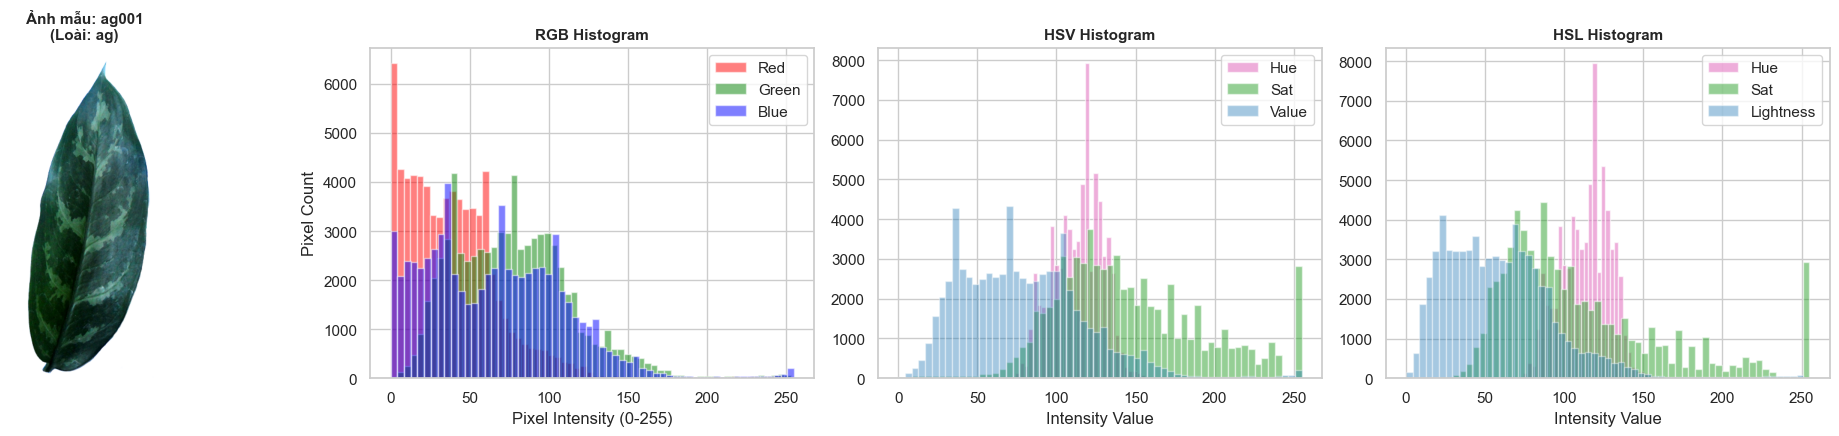

In [10]:
target_species = ['begora', 'cisds', 'ag', 'i']
sample_row = df_train[df_train["label"].isin(target_species)].iloc[0]

# Đọc đường dẫn từ cột 'path'
sample_path = Path(sample_row["path"])

# Kiểm tra đường dẫn: nếu đường dẫn lưu theo máy khác, điều chỉnh về thư mục hiện tại
if not sample_path.exists():
    # Thử tìm trong data/raw nếu bạn để ảnh ở đây
    local_alt = ROOT_DIR / "data" / "raw" / sample_path.name
    if local_alt.exists():
        sample_path = local_alt
    else:
        raise FileNotFoundError(f"Không tìm thấy file ảnh tại: {sample_path}")

print(f"Đang đọc ảnh mẫu: {sample_path}")
bgr_img = cv2.imread(str(sample_path))
rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
hsv_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV)
hsl_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HLS)

# Tạo mặt nạ nhị phân tách nền trắng (chỉ giữ pixel vùng phiến lá)
gray = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)
leaf_mask = gray < 250

rgb_leaf = rgb_img[leaf_mask]
hsv_leaf = hsv_img[leaf_mask]
hsl_leaf = hsl_img[leaf_mask]

# Vẽ biểu đồ Histogram đối sánh 3 không gian
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

axes[0].imshow(rgb_img)
axes[0].set_title(f"Ảnh mẫu: {sample_path.stem}\n(Loài: {sample_row['label']})", fontsize=11, fontweight="bold")
axes[0].axis("off")

# RGB Histogram
axes[1].hist(rgb_leaf[:, 0], bins=60, color='red', alpha=0.5, label='Red')
axes[1].hist(rgb_leaf[:, 1], bins=60, color='green', alpha=0.5, label='Green')
axes[1].hist(rgb_leaf[:, 2], bins=60, color='blue', alpha=0.5, label='Blue')
axes[1].set_title("RGB Histogram", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Pixel Intensity (0-255)")
axes[1].set_ylabel("Pixel Count")
axes[1].legend()

# HSV Histogram
axes[2].hist(hsv_leaf[:, 0] * (255/180), bins=60, color='#e377c2', alpha=0.6, label='Hue')
axes[2].hist(hsv_leaf[:, 1], bins=60, color='#2ca02c', alpha=0.5, label='Sat')
axes[2].hist(hsv_leaf[:, 2], bins=60, color='#1f77b4', alpha=0.4, label='Value')
axes[2].set_title("HSV Histogram", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Intensity Value")
axes[2].legend()

# HSL Histogram
axes[3].hist(hsl_leaf[:, 0] * (255/180), bins=60, color='#e377c2', alpha=0.6, label='Hue')
axes[3].hist(hsl_leaf[:, 2], bins=60, color='#2ca02c', alpha=0.5, label='Sat')
axes[3].hist(hsl_leaf[:, 1], bins=60, color='#1f77b4', alpha=0.4, label='Lightness')
axes[3].set_title("HSL Histogram", fontsize=11, fontweight="bold")
axes[3].set_xlabel("Intensity Value")
axes[3].legend()

plt.tight_layout()
plt.show()

# 3. Thống kê kết cấu & Viền lá
- Thống kê ma trận mức xám GLCM (Haralick Features)
- Thống kê viền mép (Contour Curvature & Roundness)

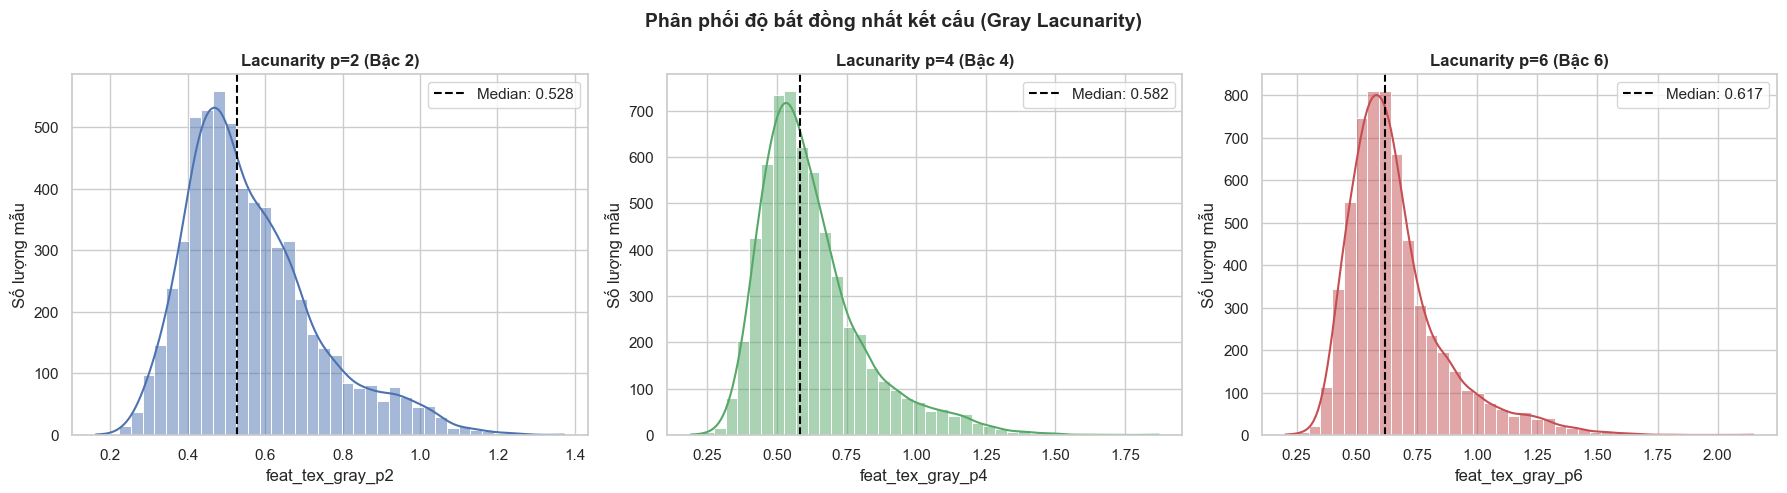

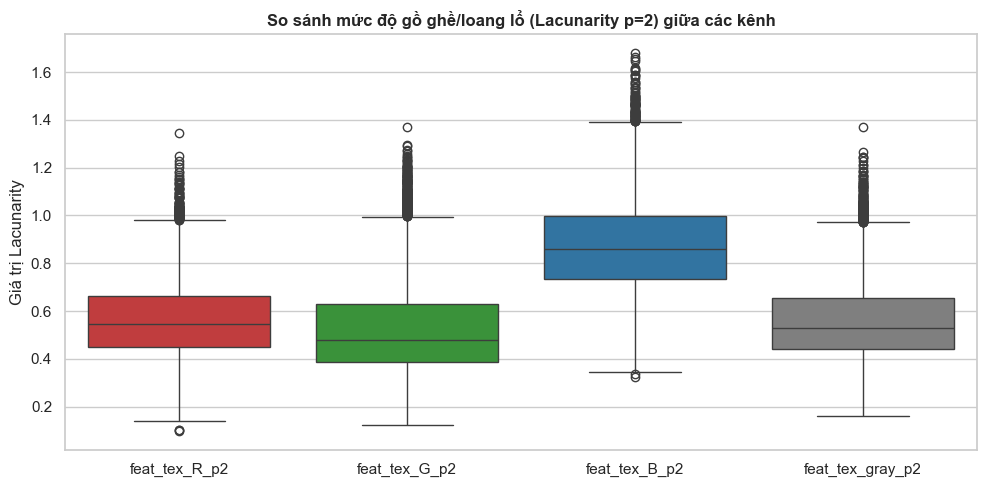

In [3]:
from configs.config import TEX_COLS, GEO_COLS, PFT_COLS

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
gray_cols = ["feat_tex_gray_p2", "feat_tex_gray_p4", "feat_tex_gray_p6"]
titles = ["Lacunarity p=2 (Bậc 2)", "Lacunarity p=4 (Bậc 4)", "Lacunarity p=6 (Bậc 6)"]
palette = ["#4c72b0", "#55a868", "#c44e52"]

for idx, col in enumerate(gray_cols):
    sns.histplot(df_train[col], bins=40, kde=True, color=palette[idx], ax=axes[idx])
    med_val = df_train[col].median()
    axes[idx].axvline(med_val, color="black", linestyle="--", label=f"Median: {med_val:.3f}")
    axes[idx].set_title(titles[idx], fontsize=12, fontweight="bold")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Số lượng mẫu")
    axes[idx].legend()

plt.suptitle("Phân phối độ bất đồng nhất kết cấu (Gray Lacunarity)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 2. ĐỘ PHỨC TẠP KẾT CẤU GIỮA CÁC KÊNH MÀU (R vs G vs B) ──
# So sánh bậc p=2 trên từng kênh màu để xem gân/hoa văn nổi bật ở kênh nào
fig, ax = plt.subplots(figsize=(10, 5))
color_tex_p2 = ["feat_tex_R_p2", "feat_tex_G_p2", "feat_tex_B_p2", "feat_tex_gray_p2"]
sns.boxplot(data=df_train[color_tex_p2], palette=["#d62728", "#2ca02c", "#1f77b4", "#7f7f7f"], ax=ax)
ax.set_title("So sánh mức độ gồ ghề/loang lổ (Lacunarity p=2) giữa các kênh", fontsize=12, fontweight="bold")
ax.set_ylabel("Giá trị Lacunarity")
plt.tight_layout()
plt.show()

**Nhận xét**
- Xu hướng phân phối lệch phải: Phân phối giá trị Lacunarity trên ảnh mức xám (feat_tex_gray) ở cả 3 bậc mô-men ($p=2, 4, 6$) đều lệch phải rõ rệt với trung vị tăng tịnh tiến từ 0.528, 0.582 đến 0.617. 

- Phản ánh bản chất bề mặt sinh học: Đa số mẫu ảnh tập trung ở vùng giá trị thấp tương ứng với bề mặt lá trơn nhẵn, trong khi dải đuôi dài kéo sang phải đại diện cho các loài có mạng lưới gân lá nổi gồ ghề hoặc hoa văn đốm loang phức tạp.

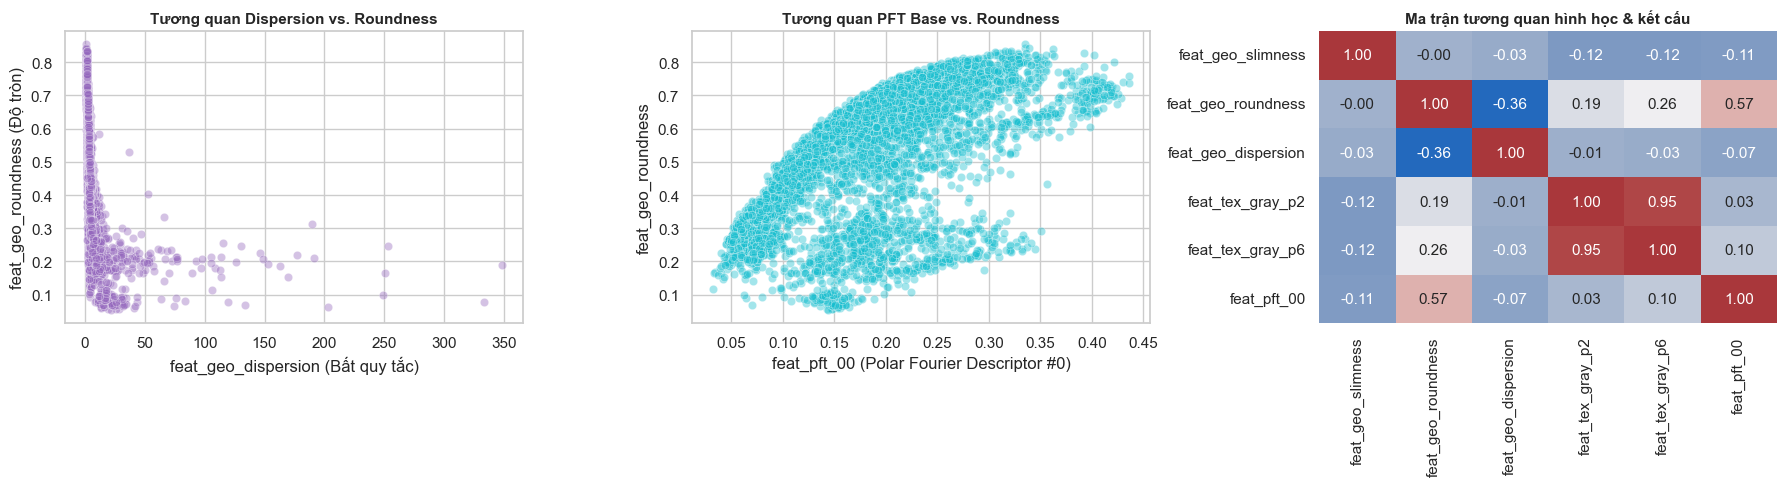

TOP 5 LOÀI CÓ KẾT CẤU BỀ MẶT THÔ RÁP / LOANG MÀU NHẤT (feat_tex_gray_p2 cao nhất):


label
pb      1.022304
i       0.950901
pcj     0.915004
cobm    0.825263
ungu    0.785482
Name: feat_tex_gray_p2, dtype: float64


TOP 5 LOÀI CÓ ĐỘ GẬP GHỀNH VIỀN / XẺ THÙY NHẤT (feat_geo_dispersion cao nhất):


label
ct       57.392391
manes    30.948164
cu       18.019128
Y        10.734053
ap       10.654862
Name: feat_geo_dispersion, dtype: float64

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A. Tương quan nghịch giữa Roundness và Dispersion
sns.scatterplot(
    data=df_train,
    x="feat_geo_dispersion",
    y="feat_geo_roundness",
    alpha=0.4,
    color="#9467bd",
    ax=axes[0]
)
axes[0].set_title("Tương quan Dispersion vs. Roundness", fontsize=11, fontweight="bold")
axes[0].set_xlabel("feat_geo_dispersion (Bất quy tắc)")
axes[0].set_ylabel("feat_geo_roundness (Độ tròn)")

# B. Kết cấu viền mép vs Năng lượng Fourier bậc thấp (PFT 00)
sns.scatterplot(
    data=df_train,
    x="feat_pft_00",
    y="feat_geo_roundness",
    alpha=0.4,
    color="#17becf",
    ax=axes[1]
)
axes[1].set_title("Tương quan PFT Base vs. Roundness", fontsize=11, fontweight="bold")
axes[1].set_xlabel("feat_pft_00 (Polar Fourier Descriptor #0)")
axes[1].set_ylabel("feat_geo_roundness")

# C. Ma trận tương quan giữa các đặc trưng hình học & kết cấu chính
focus_cols = ["feat_geo_slimness", "feat_geo_roundness", "feat_geo_dispersion", 
              "feat_tex_gray_p2", "feat_tex_gray_p6", "feat_pft_00"]
corr = df_train[focus_cols].corr()
sns.heatmap(corr, annot=True, cmap="vlag", fmt=".2f", ax=axes[2], cbar=False)
axes[2].set_title("Ma trận tương quan hình học & kết cấu", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

# ── 4. XẾP HẠNG LOÀI CÓ ĐẶC TRƯNG MẶT LÁ & VIỀN MỚI ──
print("=" * 65)
print("TOP 5 LOÀI CÓ KẾT CẤU BỀ MẶT THÔ RÁP / LOANG MÀU NHẤT (feat_tex_gray_p2 cao nhất):")
display(df_train.groupby("label")["feat_tex_gray_p2"].mean().sort_values(ascending=False).head(5))

print("\nTOP 5 LOÀI CÓ ĐỘ GẬP GHỀNH VIỀN / XẺ THÙY NHẤT (feat_geo_dispersion cao nhất):")
display(df_train.groupby("label")["feat_geo_dispersion"].mean().sort_values(ascending=False).head(5))
print("=" * 65)

**Nhận xét**
- Tính đồng nhất giữa biến đổi chuỗi Fourier và độ tròn: Mối tương quan thuận mạnh mẽ giữa feat_pft_00 và feat_geo_roundness ($r = 0.57$) chứng minh thành phần năng lượng tần số thấp của Polar Fourier Transform phản ánh chính xác kích thước và diện mạo tổng thể của phiến lá.

- Tính độc lập giữa các nhóm đặc trưng: Ma trận tương quan chỉ ra các chỉ số kết cấu mức xám (feat_tex_gray_p2, feat_tex_gray_p6) gần như không phụ thuộc tuyến tính vào các thuộc tính hình học viền ($\vert{}r\vert{} \le 0.12$), khẳng định việc kết hợp đa phương thức (hình học, viền mép, kết cấu) không gây dư thừa dữ liệu mà bổ trợ trực tiếp cho mô hình phân loại.

# 4. Thống kê phân phối nhãn & Khả năng tách cụm
- Kiểm định cân bằng dữ liệu (Class Balance)

- Chiếu giảm chiều trực quan hóa không gian đặc trưng (t-SNE / PCA Projection)

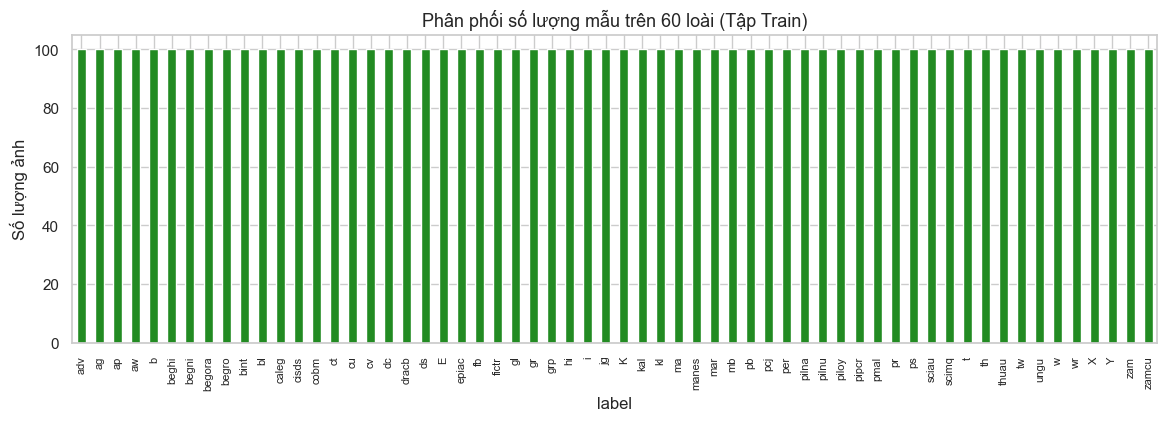

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
df_train["label"].value_counts().plot(kind="bar", ax=ax, color="forestgreen")
ax.set_title("Phân phối số lượng mẫu trên 60 loài (Tập Train)", fontsize=13)
ax.set_ylabel("Số lượng ảnh")
plt.xticks(rotation=90, fontsize=8)
plt.show()

**Nhận xét**
Không xảy ra tình trạng mất cân bằng giữa các lớp. Đây là một dataset rất tốt về tỉ lệ.


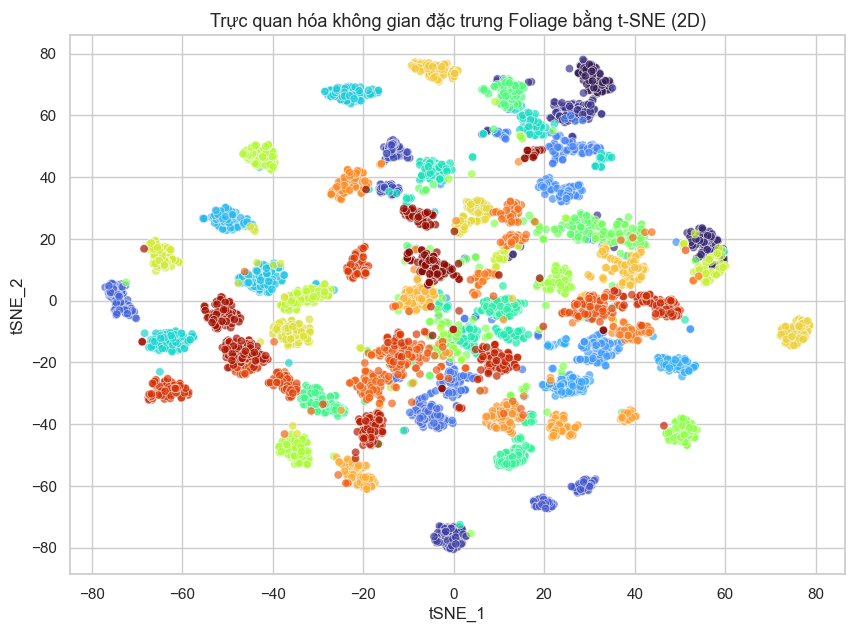

In [6]:
X_scaled = StandardScaler().fit_transform(df_train[FEATURE_COLS])

tsne = TSNE(n_components=2, perplexity=30, random_state=2026)
X_tsne = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame(X_tsne, columns=["tSNE_1", "tSNE_2"])
df_tsne["label"] = df_train["label"]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_tsne, 
    x="tSNE_1", 
    y="tSNE_2", 
    hue="label", 
    legend=False, 
    palette="turbo", 
    alpha=0.7
)
plt.title("Trực quan hóa không gian đặc trưng Foliage bằng t-SNE (2D)", fontsize=13)
plt.show()

**Nhận xét**
Ta thấy các lớp có khả năng phân tách tốt, có 1 số cụm có tình trạng xếp chồng lên nhau tuy nhiên khả năng phân biệt vẫn có. Ở các vùng trung tâm hoặc lệch phải 20 đv, ta thấy được mật độ các lớp rất cao ở đây. 
